# Examples of How To Define ACSets

Nelson Niu  
Nathaniel Osgood  
Priyaa Srinivasan  
Jacob Zelko  
Juxin Liu  
2026-02-26

## Background

Helper method for showing graphviz from quarto markdown:

In [1]:
function show_graphviz(g)
    buf = IOBuffer()
    run_graphviz(buf, g, format="png")
    display(MIME("image/png"), take!(buf))
end

show_graphviz (generic function with 1 method)

## Catlab Set-Up

In [2]:
import Catlab.CategoricalAlgebra:
  @acset,
  @acset_type,
  @acset_colim,
  @present,
  FreeSchema,
  elements,
  nparts,
  representable,
  set_subpart!,
  src,
  subobject_classifier,
  tgt,
  yoneda
import Catlab.Graphs:
  NamedGraph
import Catlab.Graphics:
  to_graphviz
import Catlab.Graphics.Graphviz: 
  run_graphviz

In [3]:
ng = NamedGraph{Symbol, Symbol}

NamedGraph{Symbol, Symbol}

In [4]:
y_ng = yoneda(ng)

Catlab.CategoricalAlgebra.Cats.FinFunctors.FinDomMap.FinDomFunctorMap{Union{Catlab.Theories.FreeSchema.AttrType{:generator}, Catlab.Theories.FreeSchema.Ob{:generator}}, ACSets.ACSetInterface.ACSet, Union{Catlab.Theories.FreeSchema.Attr, Catlab.Theories.FreeSchema.Hom}, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.ACSetTransformation, Union{Catlab.Theories.FreeSchema.Attr{:generator}, Catlab.Theories.FreeSchema.Hom{:generator}}, Dict{GATlab.Models.SymbolicModels.GATExpr{:generator}, NamedGraph{Symbol, Symbol}}, Dict{GATlab.Models.SymbolicModels.GATExpr{:generator}, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:V, :E}, Tuple{(:src, :E, :V), (:tgt, :E, :V)}, Tuple{:VName, :EName}, Tuple{(:vname, :V, :VName), (:ename, :E, :EName)}, Tuple{}}, @NamedTuple{VName::Catlab.BasicSets.CopairedFinDomFunctions.CopairedFinDomFunction{Symbol, Int64, Int64}, EName::Catlab.BasicSets.CopairedFinDomFunction

In [5]:
ng1 = @acset_colim y_ng begin
  # First Component
  (v1,v2,v3,v4,v5,v6)::V
  (e1,e2,e3,e4,e5,e6)::E

  # To reduce brutal repetition, like "ename(e6) == $(:E6);" for each edge, we will perform this naming below in a single comprehension.
  src(e1) == v1; tgt(e1)==v2;
  src(e2) == v2; tgt(e2)==v3;
  src(e3) == v2; tgt(e3)==v3;
  src(e4) == v4; tgt(e4)==v2;
  src(e5) == v4; tgt(e5)==v5;
  src(e6) == v6; tgt(e6)==v5;


  # Second component
  (v7,v8,v9)::V
  (e7,e8)::E

  src(e7) == v7; tgt(e7) == v8;
  src(e8) == v7; tgt(e8) == v9;


  # Third component
  (v10)::V
end

V,vname
1,AttrVar(1)
2,AttrVar(2)
3,AttrVar(3)
4,AttrVar(4)
5,AttrVar(5)
6,AttrVar(6)
7,AttrVar(7)
8,AttrVar(8)
9,AttrVar(9)
10,AttrVar(10)


In [6]:
set_subpart!(ng1, :ename, Symbol.("E$e" for e in 1:nparts(ng1, :E)));

In [7]:
set_subpart!(ng1, :vname, Symbol.("V$v" for v in 1:nparts(ng1, :V)));

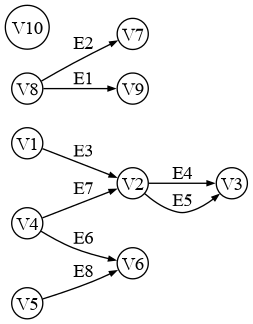

In [8]:
to_graphviz(ng1, node_labels=true, edge_labels=true) |> show_graphviz

In [9]:
# We now declaratively characterize this in traditional syntax

In [10]:
graph_1Manual = @acset ng begin
  V = 10
  E = 8

  src = [1, 2, 2, 4, 4, 6, 7, 7] # Source vector
  tgt = [2, 3, 3, 2, 5, 5, 8, 9]  # Target vector
end

V,vname
1,nothing
2,nothing
3,nothing
4,nothing
5,nothing
6,nothing
7,nothing
8,nothing
9,nothing
10,nothing


In [11]:
set_subpart!(graph_1Manual, :vname, Symbol.("V$v" for v in 1:10));

In [12]:
set_subpart!(graph_1Manual, :ename, Symbol.("E$e" for e in 1:8));